In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Módulo para manejo de imágenes
import pandas as pd
from PIL import Image
from pathlib import Path

def process_image(img_path : str, rotate=False) -> np.ndarray:
    img = Image.open(img_path).convert("L")
    img_matrix = np.array(img)
    if rotate:
        return np.rot90(img_matrix, 2)
    return img_matrix

def read_images(folder : Path, csv : pd.DataFrame) -> np.ndarray:
    images = []
    tags = []
    for _, row in csv.iterrows():
        image_name = row["archivo"]
        tag = row["clase"]

        image_path = folder / image_name
        if image_path.exists():
            img_matrix = process_image(image_path)
        else:
            print("Image not found: ", image_name)
            return None, None
        images.append(img_matrix)
        tags.append(tag)
    return np.array(images), np.array(tags) # Matrix con filas las realizaciones y Vector con las etiquetas asociadas

def flatten_images(images):
    return images.reshape(images.shape[0], -1)

In [34]:
# Entrenamiento y testeo de modelo
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

def train_clasifier(lr_model : LogisticRegression, X : np.ndarray, y : np.ndarray) -> None:
    lr_model.fit(X, y)
    return None
def test_clasifier(lr_model : LogisticRegression, X : np.ndarray, y : np.ndarray) -> float:
    y_pred = lr_model.predict(X)
    acc = accuracy_score(y, y_pred)
    return acc

In [35]:
# Principal Component Analysis
def _SVD(X: np.ndarray):
    mu = X.mean(axis=0)
    X_centered = X - mu
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return U, S, Vt, mu

def _K_components_train(U, S, Vt, K: int) -> np.ndarray:
    Uk, Sk = U[:, :K], S[:K]
    return Uk @ np.diag(Sk)

def _K_components_test(X_test, Vt, mu, K: int) -> np.ndarray:
    Vk = Vt[:K, :].T                    # (d, K)
    X_test_centered = X_test - mu       # centered with train mean (part of the PCA 'training')
    return X_test_centered @ Vk

In [36]:
# Inciso B
def proyectar_componentes(X_train: np.ndarray, X_test: np.ndarray, K: int):
    """
    Calcula la matriz de proyección (V) a partir de X_train,
    y proyecta tanto train como test sobre las primeras K componentes principales.
    """
    mu = X_train.mean(axis=0)
    X_train_centered = X_train - mu

    U, S, Vt = np.linalg.svd(X_train_centered, full_matrices=False)
    Vk = Vt[:K, :].T  # matriz de proyección: (d, K)

    X_train_proj = X_train_centered @ Vk
    X_test_proj = (X_test - mu) @ Vk

    return X_train_proj, X_test_proj

In [37]:
# Inciso C
N = 2000

def K_PCA(X_train, y_train, X_test, y_test, Kmin=1, Kmax=100):
    Ks = []
    accuarcies = []
    U_train, S_train, Vt_train, mu_train = _SVD(X_train)  # SVD solo una vez, solo con train

    for K in range(Kmin, Kmax+1):
        lr_model = LogisticRegression(max_iter=N)
        Xk_train = _K_components_train(U_train, S_train, Vt_train, K)
        Xk_test = _K_components_test(X_test, Vt_train, mu_train, K)

        train_clasifier(lr_model, Xk_train, y_train)
        accuarcy = test_clasifier(lr_model, Xk_test, y_test)
        Ks.append(K)
        accuarcies.append(accuarcy)

    return np.array(Ks), np.array(accuarcies)


Accuarcy reported:  0.8183760683760684


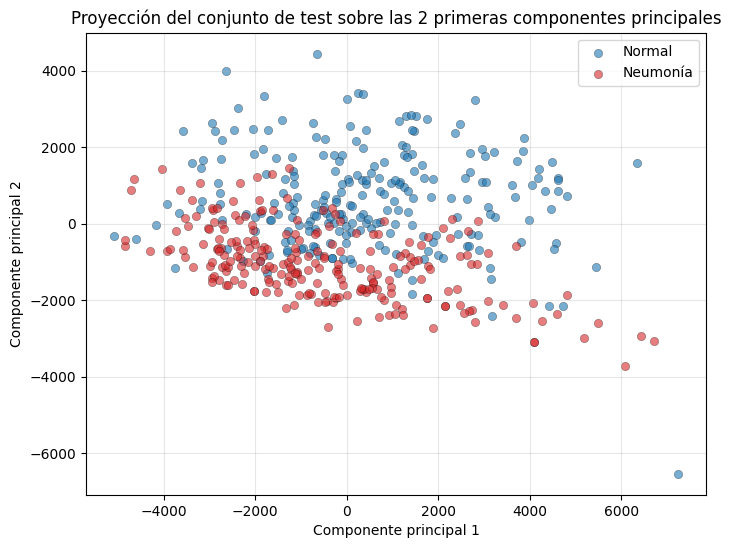

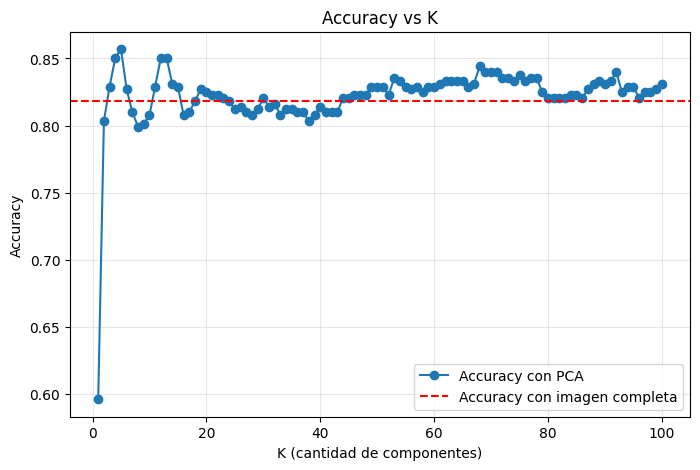

In [41]:
if __name__ == "__main__":
    training_folder = Path("../dataset_tp1/train")
    df_train = pd.read_csv("../dataset_tp1/train_labels.csv")
    X_train, y_train = read_images(training_folder, df_train)
    X_train = flatten_images(X_train)

    testing_folder = Path("../dataset_tp1/test")
    df_test = pd.read_csv("../dataset_tp1/test_labels.csv")
    X_test, y_test = read_images(testing_folder, df_test)
    X_test = flatten_images(X_test)

    # Without PCA
    lr_model = LogisticRegression(max_iter=N)
    train_clasifier(lr_model, X_train, y_train)
    accuracy_full = test_clasifier(lr_model, X_test, y_test)
    print("Accuarcy reported: ", accuracy_full)

    # K = 2 (B)
    # Proyección sobre las 2 primeras componentes principales
    X_train_proj, X_test_proj = proyectar_componentes(X_train, X_test, K=2)

    # Scatter diferenciando clases por color
    plt.figure(figsize=(8, 6))
    colores = {0: "tab:blue", 1: "tab:red"}
    etiquetas = {0: "Normal", 1: "Neumonía"}

    for clase in [0, 1]:
        mask = y_test == clase
        plt.scatter(
            X_test_proj[mask, 0],
            X_test_proj[mask, 1],
            c=colores[clase],
            label=etiquetas[clase],
            alpha=0.6,
            edgecolors="k",
            linewidths=0.3,
        )

    plt.xlabel("Componente principal 1")
    plt.ylabel("Componente principal 2")
    plt.title("Proyección del conjunto de test sobre las 2 primeras componentes principales")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



    # With PCA, graph showing for different Ks (C)
    Ks, accuracies = K_PCA(X_train, y_train, X_test, y_test)    

    plt.figure(figsize=(8, 5))
    # Puntos (K, accuracy)
    plt.plot(Ks, accuracies, marker="o", linestyle="-", label="Accuracy con PCA")

    # Dotted line for full picture accuracy
    plt.axhline(y=accuracy_full, color="red", linestyle="--", label="Accuracy con imagen completa")

    plt.xlabel("K (cantidad de componentes)")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs K")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()